In [2]:
import scipy.io as sio
import numpy as np
from scipy.signal import butter, filtfilt
from mne.decoding import CSP
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm, trange
import matplotlib.pyplot as plt
from tqdm import trange
import numpy as np
import torch
from torch.utils.data import random_split 
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
def bandpass_filter(data, lowcut=8, highcut=30, fs=250, order=4):
    """Applies a Butterworth bandpass filter to EEG data."""
    nyquist = 0.5 * fs  # Nyquist frequency
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=-1)

In [4]:
def load_BCI2a_data(data_path, subject, training, all_trials=True):    
    # Define MI-trials parameters
    n_channels = 22
    n_tests = 6 * 48     
    window_Length = 7 * 250  # Total trial duration (7s)

    # Define MI trial window 
    fs = 250          # Sampling rate
    t1 = int(2 * fs)  # Start time_point (2s)
    t2 = int(6 * fs)  # End time_point (6s)

    class_return = np.zeros(n_tests)
    data_return = np.zeros((n_tests, n_channels, window_Length))  #(trials x channels x time)

    NO_valid_trial = 0
    if training:
        a = sio.loadmat(data_path + 'A0' + str(subject + 1) + 'T.mat')   #()
    else:
        a = sio.loadmat(data_path + 'A0' + str(subject + 1) + 'E.mat')

    a_data = a['data']  #()
    
    for ii in range(a_data.size):
        a_data1 = a_data[0, ii]
        a_data2 = [a_data1[0, 0]]
        a_data3 = a_data2[0]
        a_X = a_data3[0]  # EEG signals
        a_trial = a_data3[1]  # Trial start indices
        a_y = a_data3[2]  # Class labels
        a_artifacts = a_data3[5]  # Artifact presence

        for trial in range(a_trial.size):
            if a_artifacts[trial] != 0 and not all_trials:
                continue
            # Extract EEG trial (time x channels) and transpose to (channels x time)
            trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
            
            # Apply bandpass filter
            trial_data = bandpass_filter(trial_data, lowcut=8, highcut=30, fs=fs, order=4)

            data_return[NO_valid_trial, :, :] = trial_data
            class_return[NO_valid_trial] = int(a_y[trial])
            NO_valid_trial += 1        

    # Keep only valid trials and select MI window (2s to 6s)
    data_return = data_return[0:NO_valid_trial, :, t1:t2]
    class_return = class_return[0:NO_valid_trial]
    class_return = (class_return - 1).astype(int)  # Convert to zero-based index

    return data_return, class_return

In [5]:
import torch
import numpy as np
from torch_geometric.data import Data, Dataset
from itertools import combinations

class EEGGraphDataset(Dataset):
    def __init__(self, X, y, indices, loader_type, sfreq, spec_coh_values, transform=None):
        self.epochs = X                  # shape: [n_samples, 22 x T]
        self.labels = y
        self.indices = indices
        self.sfreq = sfreq
        self.loader_type = loader_type
        self.transform = transform
        self.spec_coh_values = spec_coh_values  # shape: [n_samples, 231]

        self.ch_names = [
            'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
            'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
            'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
            'P1', 'Pz', 'P2', 'POz'
        ]

        self.node_ids = list(range(len(self.ch_names)))  # [0..21]

        # Build undirected edge index for upper triangle (no self-loops)
        edge_list = list(combinations(self.node_ids, 2))  # 231 edges
        self.edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.item()

        real_idx = self.indices[idx]

        # Shape: [22, time_steps]
        node_features = torch.from_numpy(self.epochs[real_idx].reshape(22, -1)).float()

        # Get spectral coherence values for current sample: shape [231]
        edge_weights = torch.tensor(self.spec_coh_values[real_idx], dtype=torch.float32)

        return Data(
            x=node_features,
            edge_index=self.edge_index,
            edge_attr=edge_weights,
            dataset_idx=real_idx,
            y=torch.tensor(self.labels[real_idx], dtype=torch.long)
        )

In [6]:
class GraphTransformerNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=3, transformer_heads=4, transformer_layers=3, dropouts=0.5):
        super().__init__()
        self.graph_block = GraphConvBlock(in_channels, hidden_channels)
        self.cheb_block = ChebConvBlock(in_channels, hidden_channels, K)
        self.sage_block = SAGEConvBlock(in_channels, hidden_channels)

        self.feature_dim = (hidden_channels // 2) * 3
        assert self.feature_dim % transformer_heads == 0, "embed_dim must be divisible by num_heads"

        self.transformer = TransformerBlock(
            input_dim=self.feature_dim,
            nhead=transformer_heads,
            num_layers=transformer_layers
        )

        self.mlp = nn.Sequential(
            nn.Linear(self.feature_dim, hidden_channels),
            nn.ReLU(),
            nn.LayerNorm(hidden_channels),
            nn.Dropout(dropouts),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.LayerNorm(hidden_channels // 2),
            nn.Dropout(dropouts),
            nn.Linear(hidden_channels // 2, out_channels)
        )

    def forward_gnn(self, x, edge_index, edge_attr, batch):
        """Return GNN embeddings only (before transformer/MLP)."""
        g1 = self.graph_block(x, edge_index, edge_attr, batch)   # uses edge weights
        g2 = self.cheb_block(x, edge_index, edge_attr, batch)
        g3 = self.sage_block(x, edge_index, edge_attr, batch)
        return torch.cat([g1, g2, g3], dim=1)  # fused graph features

    def forward(self, x, edge_index, edge_attr, batch, return_embeddings=False):
        gnn_out = self.forward_gnn(x, edge_index, edge_attr, batch)

        x = gnn_out.unsqueeze(1)   # (batch, seq_len=1, feature_dim)
        x = self.transformer(x)
        x = x[:, 0, :]             # back to (batch, feature_dim)

        logits = self.mlp(x)

        if return_embeddings:
            return logits, gnn_out
        return logits

NameError: name 'nn' is not defined

In [7]:
import numpy as np
from scipy.signal import coherence
from tqdm import tqdm

def compute_spectral_coherence(data, sfreq=250):
    """
    Compute coherence between all pairs of channels for each sample.
    
    Args:
        data: np.ndarray, shape (samples, channels, time)
        sfreq: Sampling frequency
    
    Returns:
        np.ndarray, shape (samples, num_edges), coherence values averaged over frequencies
    """
    n_samples, n_channels, _ = data.shape
    coherence_features = []

    for sample in tqdm(data, desc="Computing coherence"):
        sample_coherence = []
        for i in range(n_channels):
            for j in range(i + 1, n_channels):
                f, coh = coherence(sample[i], sample[j], fs=sfreq, nperseg=256)
                avg_coh = np.mean(coh)  # Optionally, take band average
                sample_coherence.append(avg_coh)
        coherence_features.append(sample_coherence)

    return np.array(coherence_features)

In [ ]:
# gnn_explainer_pipeline.py
import torch
import numpy as np
from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig
import matplotlib.pyplot as plt
import mne
from copy import deepcopy
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---------- Utilities ----------

def get_base_edge_info(dataset):
    """Get canonical edge_index and (optional) edge_attr ordering from dataset[0].
       Assumes all samples share the same graph topology & ordering (typical for EEG graphs)."""
    sample = dataset[0]
    # if dataset returns numpy arrays, convert them
    edge_index = sample.edge_index
    edge_attr = getattr(sample, 'edge_attr', None)
    return edge_index, edge_attr

def single_sample_from_batch(batch, idx):
    """Given a batched PyG batch, extract the i-th graph as a separate Data object."""
    # PyG has a function torch_geometric.utils.to_data_list(batch) but to avoid import variations:
    from torch_geometric.data import Data
    # batch is a Batch object. Convert to list:
    data_list = batch.to_data_list()
    return data_list[idx]

# ---------- Build Explainer ----------
from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig

def build_explainer(model, epochs=100, lr=0.01):
    model.eval()
    model_config = ModelConfig(
        mode='binary_classification',   # string is fine
        task_level='graph',             # string is fine
        return_type='raw'               # just use 'raw' instead of ModelReturnType.raw
    )
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=epochs, lr=lr),
        explanation_type='phenomenon',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=model_config,
    )
    return explainer



# ---------- Run Explainer on dataset ----------

def explain_dataset(model, explainer, dataset, loader, class_map=(0,1), only_correct=True, max_samples_per_class=200):
    model.eval()
    edge_index, _ = get_base_edge_info(dataset)
    num_edges = edge_index.shape[1]
    num_nodes = int(edge_index.max().item()) + 1

    accum_edge_masks = {c: np.zeros(num_edges, dtype=float) for c in class_map}
    counts = {c: 0 for c in class_map}
    node_importance_list = {c: [] for c in class_map}

    # Prepare predictions for filtering correct samples
    all_preds = []
    all_labels = []
    all_datas = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, getattr(batch, 'edge_attr', None), batch.batch)
            probs = torch.sigmoid(out).squeeze()
            preds = (probs > 0.5).long().cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(batch.y.cpu().numpy().tolist())
            all_datas.append(deepcopy(batch.cpu()))

    # flatten batch -> list of individual graphs
    flat_data_list = []
    for batch in all_datas:
        flat_data_list.extend(batch.to_data_list())

    # Loop over samples
    for idx, (data, pred, label) in enumerate(tqdm(zip(flat_data_list, all_preds, all_labels),
                                                    total=len(all_labels), desc='Explaining samples')):
        if label not in class_map:
            continue
        if only_correct and (pred != label):
            continue
        if counts[label] >= max_samples_per_class:
            continue

        data = data.to(device)
        exp = explainer(
            x=data.x,
            edge_index=data.edge_index,
            edge_attr=getattr(data, 'edge_attr', None),
            batch=getattr(data, 'batch', torch.zeros(data.x.size(0), dtype=torch.long, device=device)),
            target=torch.tensor([label], device=device)
        )

        edge_mask = exp.edge_mask.detach().cpu().numpy()
        accum_edge_masks[label] += edge_mask
        counts[label] += 1

        # compute node importance for this sample
        node_imp = np.zeros(num_nodes, dtype=float)
        for e_idx in range(num_edges):
            u = edge_index[0, e_idx].item()
            v = edge_index[1, e_idx].item()
            w = edge_mask[e_idx]
            node_imp[u] += w
            node_imp[v] += w
        if node_imp.max() > 0:
            node_imp /= node_imp.max()
        node_importance_list[label].append(node_imp)

    # Aggregate per-class
    mean_edge_masks = {c: accum_edge_masks[c]/counts[c] if counts[c]>0 else np.zeros(num_edges, dtype=float)
                       for c in class_map}
    node_imps = {c: np.mean(node_importance_list[c], axis=0) if counts[c]>0 else np.zeros(num_nodes, dtype=float)
                 for c in class_map}

    return mean_edge_masks, counts, node_imps, edge_index

# ---------- Visualization: topomap + edges ----------

def plot_topomap_with_edges(node_imp, mean_edge_mask, edge_index, ch_names, montage_name='standard_1020',
                            edge_thresh=0.35, show=True, title=None):
    """
    node_imp: (n_channels,) normalized 0..1
    mean_edge_mask: (n_edges,)
    edge_index: [2, n_edges]
    ch_names: list of channel names in the same node order
    """
    # create MNE info
    sfreq = 250  # your dataset's sampling freq; only used for info creation
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    montage = mne.channels.make_standard_montage(montage_name)
    # Try to set montage; if channel names mismatch, MNE will warn and drop missing.
    info.set_montage(montage, on_missing='warn')

    # get 2D positions for channels in same order
    pos3d = np.array([montage.get_positions()['ch_pos'].get(ch, np.array([np.nan, np.nan, np.nan])) for ch in ch_names])
    # fallback: if some channels missing in montage, you must provide coordinates manually
    if np.isnan(pos3d).any():
        print("Warning: some channel positions not found in montage. Provide explicit positions for those channels.")
    pos2d = pos3d[:, :2]

    fig, ax = plt.subplots(1, 1, figsize=(6,6))
    # plot topomap (MNE expects array of length n_channels and pos 2D array)
    mne.viz.plot_topomap(node_imp, pos2d, axes=ax, show=False)
    if title:
        ax.set_title(title)

    # overlay edges above threshold
    for e_idx in range(edge_index.shape[1]):
        w = mean_edge_mask[e_idx]
        if w > edge_thresh:
            u = edge_index[0, e_idx].item()
            v = edge_index[1, e_idx].item()
            x1, y1 = pos2d[u]
            x2, y2 = pos2d[v]
            # linewidth scaled
            lw = max(0.5, 6.0 * float(w))  # tune scaling
            ax.plot([x1, x2], [y1, y2], linewidth=lw, alpha=0.8, zorder=1, linestyle='-')
    if show:
        plt.show()
    return fig, ax

# ---------- Deletion test (faithfulness) ----------

def deletion_test(model, data, node_imp, device, k_list=[1,2,3,5,8,12]):
    """
    For the single graph 'data', sequentially zero nodes from highest importance and measure model probability drop.
    Returns: dict k -> probability after deleting top-k nodes.
    """
    model.eval()
    # original prob
    data = data.to(device)
    with torch.no_grad():
        out = model(data.x, data.edge_index, getattr(data, 'edge_attr', None), data.batch).squeeze()
        orig_prob = torch.sigmoid(out).cpu().item()

    results = {}
    # create ordering
    order = np.argsort(-node_imp)  # descending
    for k in k_list:
        mask_nodes = order[:k]
        data_mod = deepcopy(data)
        # zero out node features of those nodes
        data_mod.x = data_mod.x.clone()
        data_mod.x[mask_nodes] = 0.0
        data_mod = data_mod.to(device)
        with torch.no_grad():
            out2 = model(data_mod.x, data_mod.edge_index, getattr(data_mod, 'edge_attr', None), data_mod.batch).squeeze()
            prob2 = torch.sigmoid(out2).cpu().item()
        results[k] = prob2
    return orig_prob, results

# ---------- Example usage (put all together) ----------

def run_explainer_pipeline(model, dataset, loader, ch_names,
                           max_samples_per_class=200,
                           return_embeddings=False):
    device = next(model.parameters()).device

    # (optional) collect embeddings
    gnn_embs, labels = None, None
    if return_embeddings:
        embs, lbs = [], []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                # assumes model(x, edge_index, edge_attr, batch, return_embeddings=True) -> (logits, emb)
                logits, emb = model(batch.x, batch.edge_index,
                                    getattr(batch, 'edge_attr', None),
                                    batch.batch, return_embeddings=True)
                embs.append(emb.detach().cpu())
                lbs.append(batch.y.detach().cpu())
        gnn_embs = torch.cat(embs, dim=0)
        labels  = torch.cat(lbs,  dim=0)

    # build explainer and compute per-class masks & node importances
    explainer = build_explainer(model)
    mean_edge_masks, counts, node_imps, edge_index = explain_dataset(
        model, explainer, dataset, loader,
        class_map=(0, 1),
        only_correct=True,
        max_samples_per_class=max_samples_per_class
    )

    if return_embeddings:
        return mean_edge_masks, node_imps, edge_index, gnn_embs, labels
    return mean_edge_masks, node_imps, edge_index


In [9]:
# ----------------- Training, Validation, Testing Block -----------------

from sklearn.metrics import accuracy_score, cohen_kappa_score
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
        loss = criterion(out, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_model(model, loader, device, return_preds=False):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            probs = torch.sigmoid(out)
            preds = (probs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().float().numpy())
    acc = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    if return_preds:
        return acc, kappa, all_labels, all_preds
    return acc, kappa

def train_validate_test(model, train_loader, val_loader, test_loader, device,
                        num_epochs=1000, patience=100, lr=1e-5, weight_decay=5e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    best_val_acc, best_val_kappa = 0.0, 0.0
    best_epoch, early_stop_counter = 0, 0
    best_model_state = None
    train_losses, train_accs, val_accs = [], [], []

    from tqdm import trange
    bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)
    for epoch in bar:
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        train_acc, _ = evaluate_model(model, train_loader, device)
        val_acc, val_kappa = evaluate_model(model, val_loader, device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        bar.set_postfix({
            "Train Loss": f"{train_loss:.4f}",
            "Train Acc": f"{train_acc:.4f}",
            "Val Acc": f"{val_acc:.4f}",
            "Val Kappa": f"{val_kappa:.4f}",
            "Best Val Acc": f"{best_val_acc:.4f} (Ep {best_epoch})"
        })

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. "
                  f"Best Val Acc = {best_val_acc:.4f} (Epoch {best_epoch})")
            break

    if best_model_state:
        model.load_state_dict(best_model_state)

    test_acc, test_kappa = evaluate_model(model, test_loader, device)
    print(f"\n✅ Final Test Accuracy: {test_acc:.4f}")
    print(f"📊 Final Test Kappa: {test_kappa:.4f}")

    return model, (train_losses, train_accs, val_accs)
def run_full_pipeline(model, train_loader, val_loader, test_loader,
                      test_dataset, ch_names, device):
    # Train + validate + test
    model, (train_losses, train_accs, val_accs) = train_validate_test(
        model, train_loader, val_loader, test_loader, device
    )
    # Explanations (set return_embeddings=True if you want them as well)
    mean_edge_masks, node_imps, edge_index = run_explainer_pipeline(
        model, test_dataset, test_loader, ch_names,
        max_samples_per_class=200,
        return_embeddings=False
    )

    return model, mean_edge_masks, node_imps, edge_index


# ----------------- Subject-wise Loop -----------------

for test_sub in range(0, 9):
    print(f"\n=== Subject {test_sub} held out for testing ===")

    # === Dataset preparation ===
    train_data_all, train_labels_all, test_data, test_labels = [], [], [], []
    for subi in range(0, 9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1); train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2); train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)
    train_labels_all = np.concatenate(train_labels_all, axis=0)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=False, all_trials=True)
    test_data = np.concatenate([test_data_1, test_data_2], axis=0)
    test_labels = np.concatenate([test_labels_1, test_labels_2], axis=0)

    # Binary filter (classes 0 and 1 only)
    train_mask = np.isin(train_labels_all, [0, 1])
    test_mask = np.isin(test_labels, [0, 1])
    train_data_binary, train_labels_binary = train_data_all[train_mask], train_labels_all[train_mask]
    test_data_binary, test_labels_binary = test_data[test_mask], test_labels[test_mask]

    # CSP features
    csp = CSP(n_components=16, reg=None, log=True, norm_trace=False, transform_into='average_power')
    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)
    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)

    # Graph dataset
    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh = compute_spectral_coherence(test_data_binary, sfreq=250)

    train_dataset = EEGGraphDataset(train_features, train_labels_binary,
                                    np.arange(len(train_labels_binary)),
                                    "train", sfreq=250, spec_coh_values=train_spec_coh)
    test_dataset = EEGGraphDataset(test_features, test_labels_binary,
                                   np.arange(len(test_labels_binary)),
                                   "test", sfreq=250, spec_coh_values=test_spec_coh)

    # Train/val split
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Model
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=1,
                                K=3, transformer_heads=8, dropouts=0.3).to(device)

    ch_names = [
        'Fz','FC3','FC1','FCz','FC2','FC4',
        'C5','C3','C1','Cz','C2','C4','C6',
        'CP3','CP1','CPz','CP2','CP4',
        'P1','Pz','P2','POz'
    ]

    # Train + explain
    model, mean_edge_masks, node_imps, edge_index = run_full_pipeline(
        model, train_loader, val_loader, test_loader, test_dataset, ch_names, device
    )

    # Save explanations (flatten dicts)
    edge_index_np = edge_index.cpu().numpy() if torch.is_tensor(edge_index) else edge_index
    np.savez(f"subject_{test_sub}_explanations.npz",
             mean_edge_mask_class0=mean_edge_masks[0],
             mean_edge_mask_class1=mean_edge_masks[1],
             node_imp_class0=node_imps[0],
             node_imp_class1=node_imps[1],
             edge_index=edge_index_np)



=== Subject 0 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_82209/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_82209/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9e+02 (2.2e-16 eps * 22 dim * 3.9e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Computing coherence:  79%|███████▉  | 1815/2304 [01:24<00:22, 21.41it/s]


KeyboardInterrupt: 

In [10]:
import numpy as np
import mne
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_topoplot_from_npz(
    npz_path,
    ch_names,
    class_idx=0,
    weight_thresh=0,
    cmap_name="viridis",
    node_scaling=300
):
    """
    Plot topoplot with node importances and weighted edges from .npz explanation file.
    
    Args:
        npz_path (str): Path to .npz file with keys [edge_index, node_imp_classX, mean_edge_mask_classX].
        ch_names (list): EEG channel names matching nodes.
        class_idx (int): Class index to visualize (0 or 1).
        weight_thresh (float): Minimum edge weight to plot.
        cmap_name (str): Colormap for edge visualization.
        node_scaling (float): Scale factor for node importance sizes.
    """
    # --- Load file ---
    data = np.load(npz_path, allow_pickle=True)
    edge_index = data["edge_index"]
    node_imps = data[f"node_imp_class{class_idx}"]
    edge_weights = data[f"mean_edge_mask_class{class_idx}"]

    # --- EEG montage ---
    montage = mne.channels.make_standard_montage("standard_1020")
    info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types="eeg")
    info.set_montage(montage)

    # --- Node positions (2D head layout) ---
    pos_dict = montage.get_positions()["ch_pos"]
    pos = np.array([pos_dict[ch][:2] for ch in ch_names])

    # --- Create figure ---
    fig, ax = plt.subplots(figsize=(7, 7), dpi=150)
    ax.set_aspect("equal")
    ax.axis("off")

    # --- Edge coloring setup ---
    norm = mcolors.Normalize(vmin=edge_weights.min(), vmax=edge_weights.max())
    cmap = cm.get_cmap(cmap_name)

    # --- Plot edges ---
    for (i, j), w in zip(edge_index.T, edge_weights):
        if w >= weight_thresh:
            color = cmap(norm(w))
            ax.plot(
                [pos[i][0], pos[j][0]],
                [pos[i][1], pos[j][1]],
                color=color,
                alpha=0.85,
                linewidth=1.0 + 4.0 * float(w)
            )

    # --- Plot nodes (scaled by importance) ---
# --- Plot nodes (scaled by importance) ---
    node_range = np.ptp(node_imps)  # instead of node_imps.ptp()
    node_sizes = node_scaling * (node_imps - node_imps.min()) / (node_range + 1e-8) + 50

    sc = ax.scatter(
        pos[:, 0], pos[:, 1],
        c=node_imps, cmap="Reds",
        s=node_sizes, edgecolor="k", zorder=3
    )
    # --- Add colorbar for edges ---
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Edge Weight", fontsize=12)

    # --- Add colorbar for node importance ---
    cbar_nodes = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.08)
    cbar_nodes.set_label("Node Importance", fontsize=12)

    plt.title(f"Topoplot with gradient edges (Class {class_idx})", fontsize=14)
    plt.show()

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_82209/1932693228.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


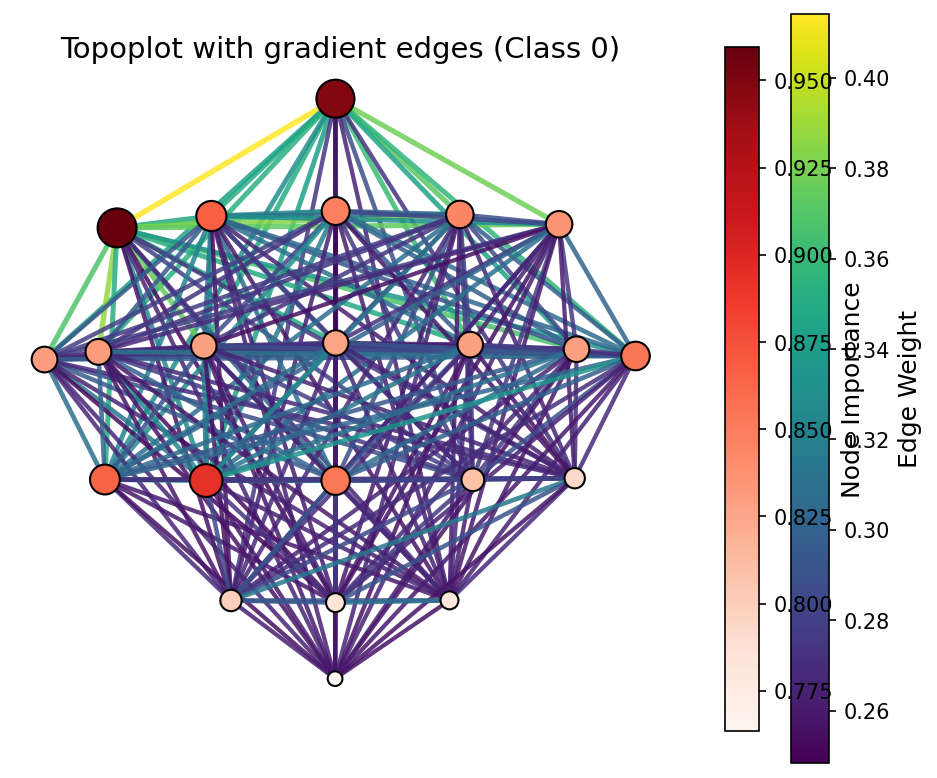

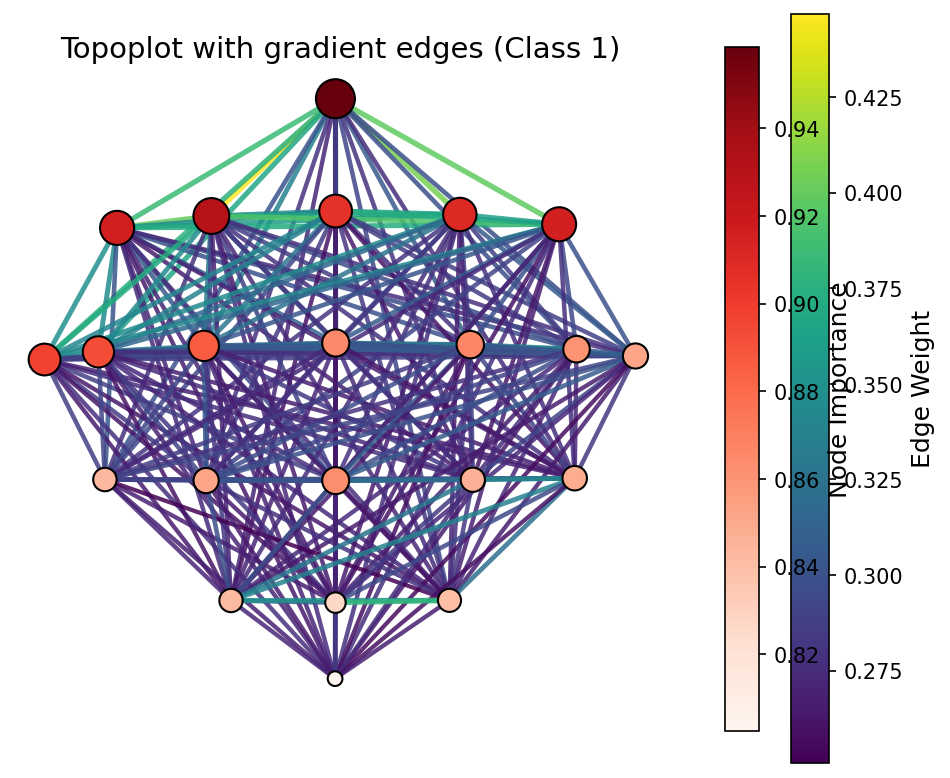

In [11]:
ch_names = [
    'Fz','FC3','FC1','FCz','FC2','FC4',
    'C5','C3','C1','Cz','C2','C4','C6',
    'CP3','CP1','CPz','CP2','CP4',
    'P1','Pz','P2','POz'
]

plot_topoplot_from_npz(
    "/Users/siddharth/Documents/Brainconnectivity/subject_0_explanations.npz",
    ch_names,
    class_idx=0  # try also with class_idx=1
)


plot_topoplot_from_npz(
    "/Users/siddharth/Documents/Brainconnectivity/subject_0_explanations.npz",
    ch_names,
    class_idx= 1 # try also with class_idx=1
)

In [35]:
import matplotlib
help(matplotlib.colors.Colormap)

Help on class Colormap in module matplotlib.colors:

class Colormap(builtins.object)
 |  Colormap(name, N=256)
 |  
 |  Baseclass for all scalar to RGBA mappings.
 |  
 |  Typically, Colormap instances are used to convert data values (floats)
 |  from the interval ``[0, 1]`` to the RGBA color that the respective
 |  Colormap represents. For scaling of data into the ``[0, 1]`` interval see
 |  `matplotlib.colors.Normalize`. Subclasses of `matplotlib.cm.ScalarMappable`
 |  make heavy use of this ``data -> normalize -> map-to-color`` processing
 |  chain.
 |  
 |  Methods defined here:
 |  
 |  __call__(self, X, alpha=None, bytes=False)
 |      Parameters
 |      ----------
 |      X : float or int, `~numpy.ndarray` or scalar
 |          The data value(s) to convert to RGBA.
 |          For floats, *X* should be in the interval ``[0.0, 1.0]`` to
 |          return the RGBA values ``X*100`` percent along the Colormap line.
 |          For integers, *X* should be in the interval ``[0, Color